# 🌍 Customer Intelligence System
### End-to-End Pipeline: Classification · Ensemble Learning · Clustering

**Techniques Used:** Random Forest · XGBoost · K-Means · DBSCAN · PCA  
**Dataset:** Country Socio-Economic & Health Data (167 countries, 9 features)

## Section 1 · Environment Setup & Imports

In [1]:
# ── Install / upgrade required packages ──────────────────────────────────────
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn

# ── Standard library ─────────────────────────────────────────────────────────
import os, warnings
warnings.filterwarnings('ignore')

# ── Numerical / Data ─────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn            as sns

# ── Sklearn – preprocessing ───────────────────────────────────────────────────
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline         import Pipeline
from sklearn.impute           import SimpleImputer

# ── Sklearn – clustering ──────────────────────────────────────────────────────
from sklearn.cluster   import KMeans, DBSCAN
from sklearn.metrics   import silhouette_score
from sklearn.decomposition import PCA

# ── Sklearn – classification / ensemble ──────────────────────────────────────
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# ── Reproducibility seed ─────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Kaggle input file listing ─────────────────────────────────────────────────
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

print("\n✅ All libraries loaded successfully!")

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv

✅ All libraries loaded successfully!


## Section 2 · Load Dataset

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv'
DICT_PATH = '/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv'

df   = pd.read_csv(DATA_PATH)
dct  = pd.read_csv(DICT_PATH)

print("📖 Data Dictionary")
print(dct.to_string(index=False))
print(f"\n📐 Dataset shape : {df.shape}  ({df.shape[0]} countries × {df.shape[1]} features)")
df.head(10)

📖 Data Dictionary
Column Name                                                                                                      Description
    country                                                                                              Name of the country
 child_mort                                                      Death of children under 5 years of age per 1000 live births
    exports                                    Exports of goods and services per capita. Given as %age of the GDP per capita
     health                                                Total health spending per capita. Given as %age of GDP per capita
    imports                                    Imports of goods and services per capita. Given as %age of the GDP per capita
     Income                                                                                            Net income per person
  Inflation                                                       The measurement of the annual growth rate

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


## Section 3 · Data Cleaning

In [3]:
# Step 1 – strip whitespace from column names
df.columns = df.columns.str.strip()
print("Columns after strip :", df.columns.tolist())

# Step 2 – drop duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed  : {before - len(df)}")

# Step 3 – coerce numeric types
num_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = [c for c in num_cols if c != 'country']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Step 4 – impute missing values with column median
feature_cols = [c for c in df.columns if c != 'country']
for col in feature_cols:
    missing = df[col].isnull().sum()
    if missing:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Imputed {missing} missing in '{col}'")

print(f"\nTotal missing after imputation : {df.isnull().sum().sum()}")
print(f"Clean dataset shape            : {df.shape}")
df.info()

Columns after strip : ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Duplicates removed  : 0

Total missing after imputation : 0
Clean dataset shape            : (167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


## Section 4 · Exploratory Data Analysis

In [4]:
print("📊 Descriptive Statistics")
df[feature_cols].describe().round(2)

📊 Descriptive Statistics


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


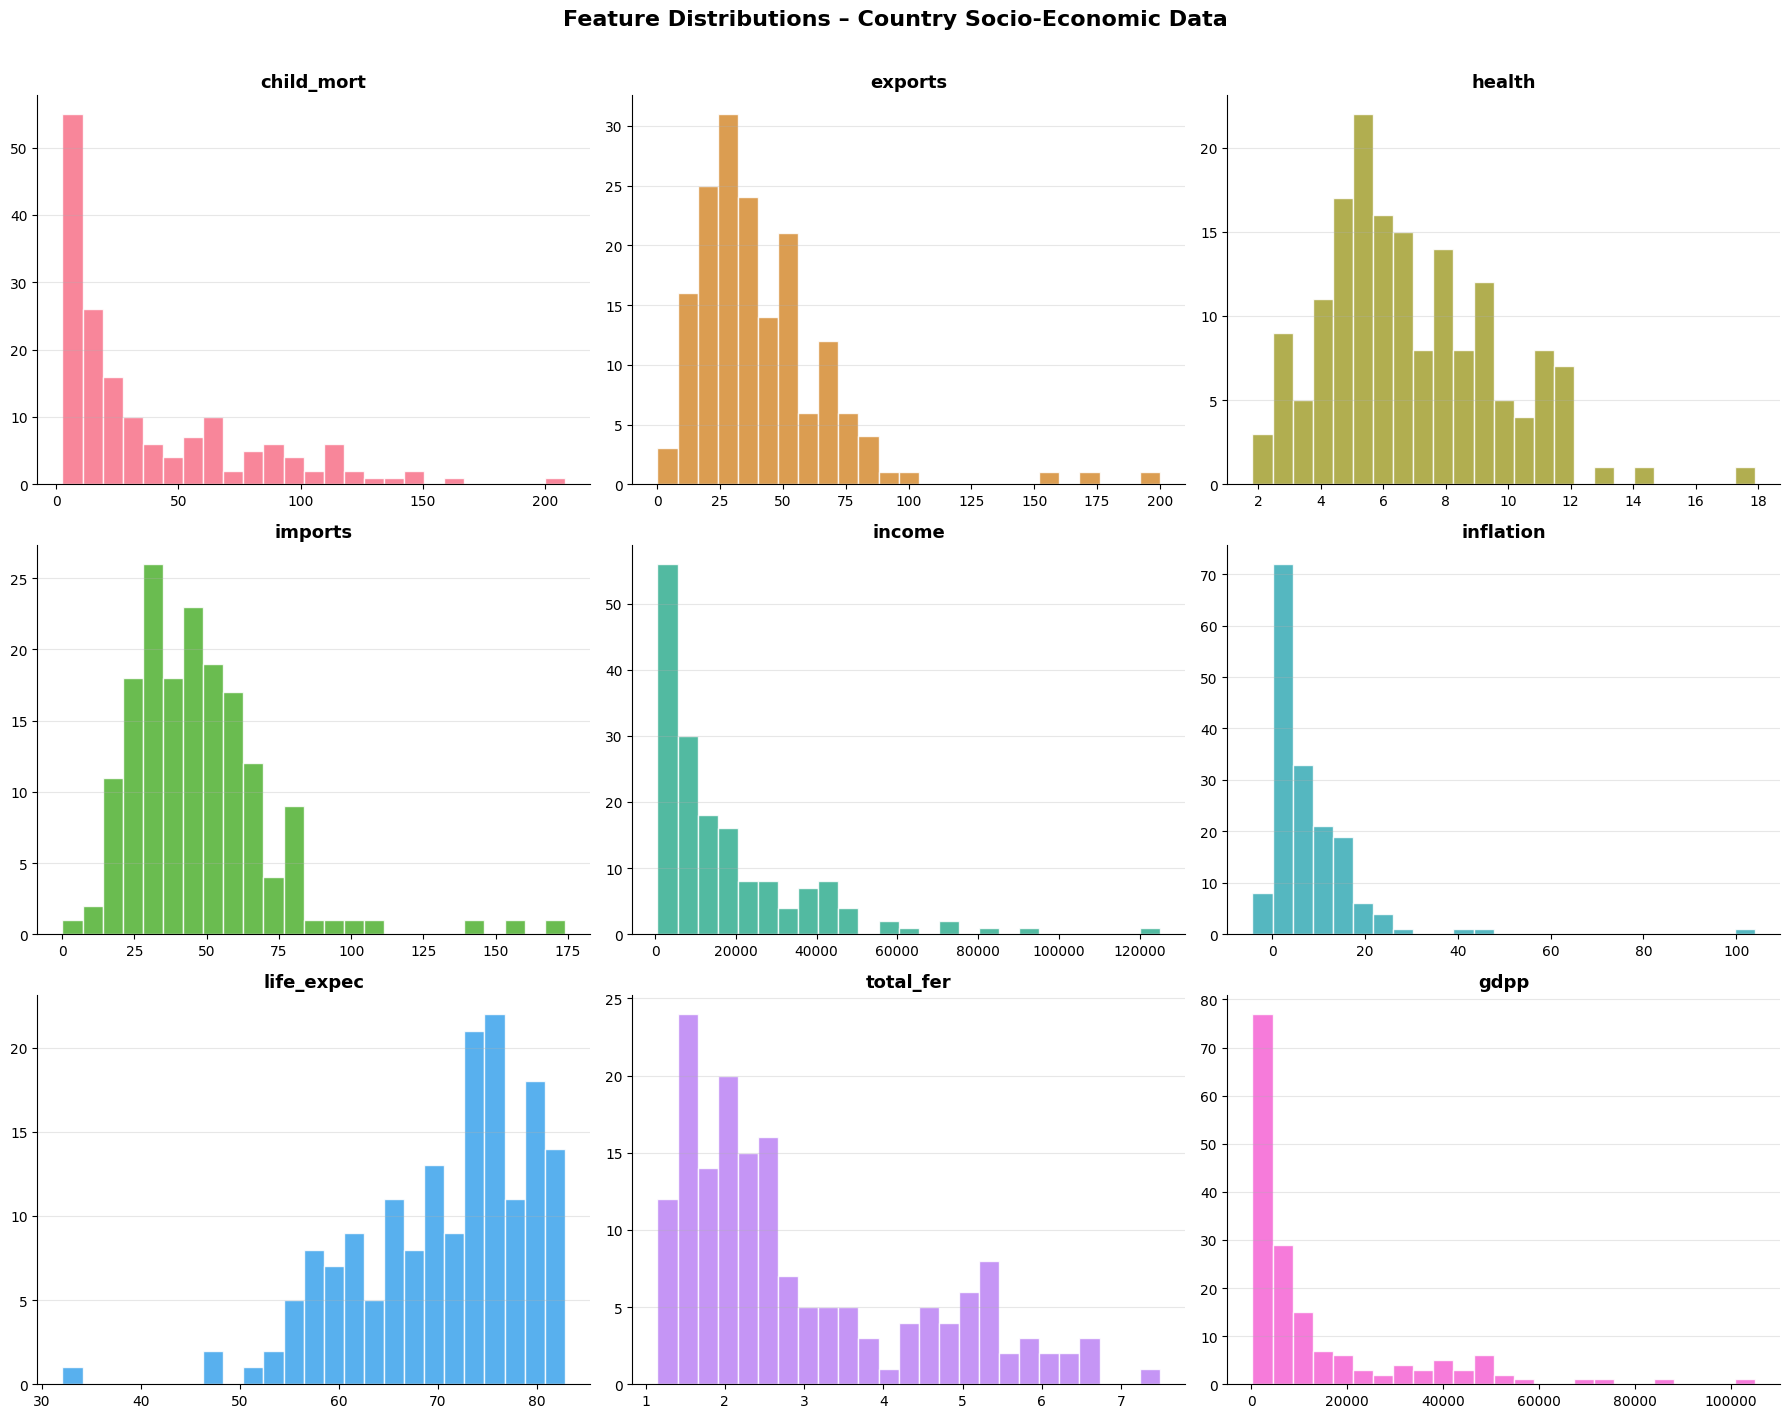

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
palette = sns.color_palette("husl", len(feature_cols))

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=25, color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].spines[['top','right']].set_visible(False)

plt.suptitle('Feature Distributions – Country Socio-Economic Data',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

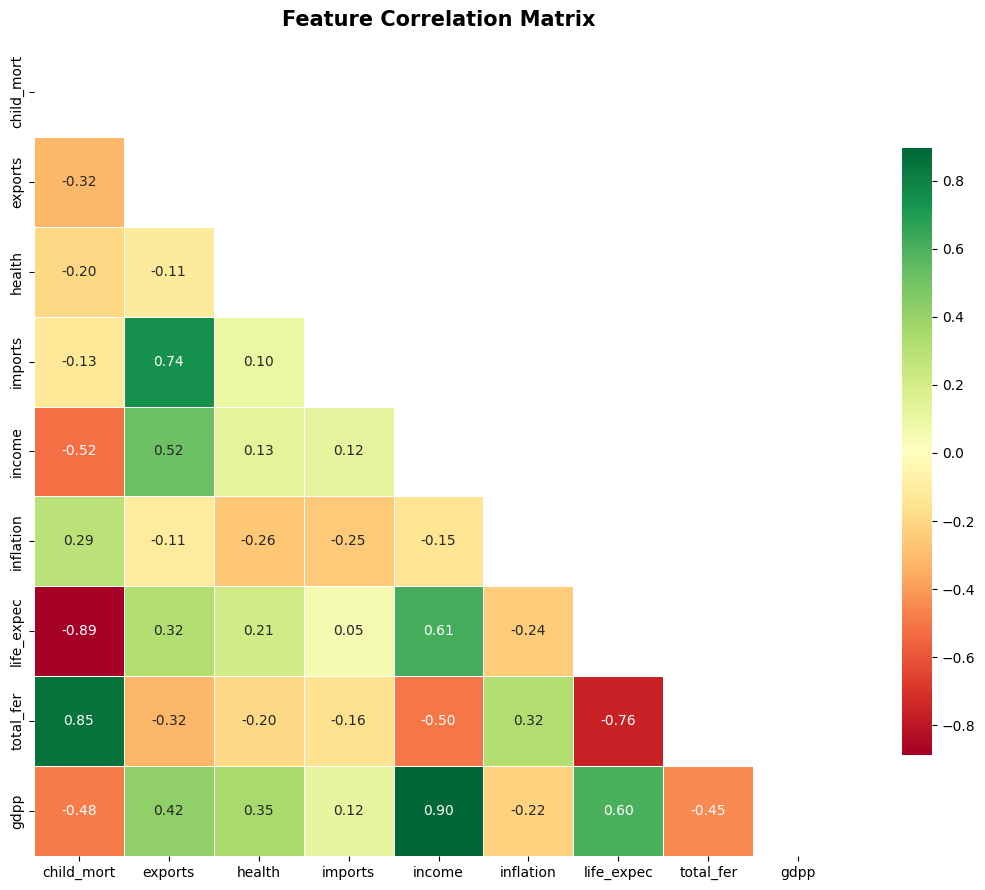

In [6]:
plt.figure(figsize=(12, 9))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    linewidths=0.5, square=True, cbar_kws={'shrink': 0.75}
)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 5 · Feature Engineering & Scaling

In [7]:
# Strip country identifier – keep only continuous features
X_raw     = df[feature_cols].copy()
countries = df['country'].values

# Scale with StandardScaler (zero-mean, unit-variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"Feature matrix shape : {X_scaled.shape}")
print("\nScaled feature stats (mean ≈ 0, std ≈ 1):")
pd.DataFrame(X_scaled, columns=feature_cols).describe().loc[['mean','std']].round(4)

Feature matrix shape : (167, 9)

Scaled feature stats (mean ≈ 0, std ≈ 1):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
mean,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003


## Section 6 · Elbow Method – Optimal K Selection

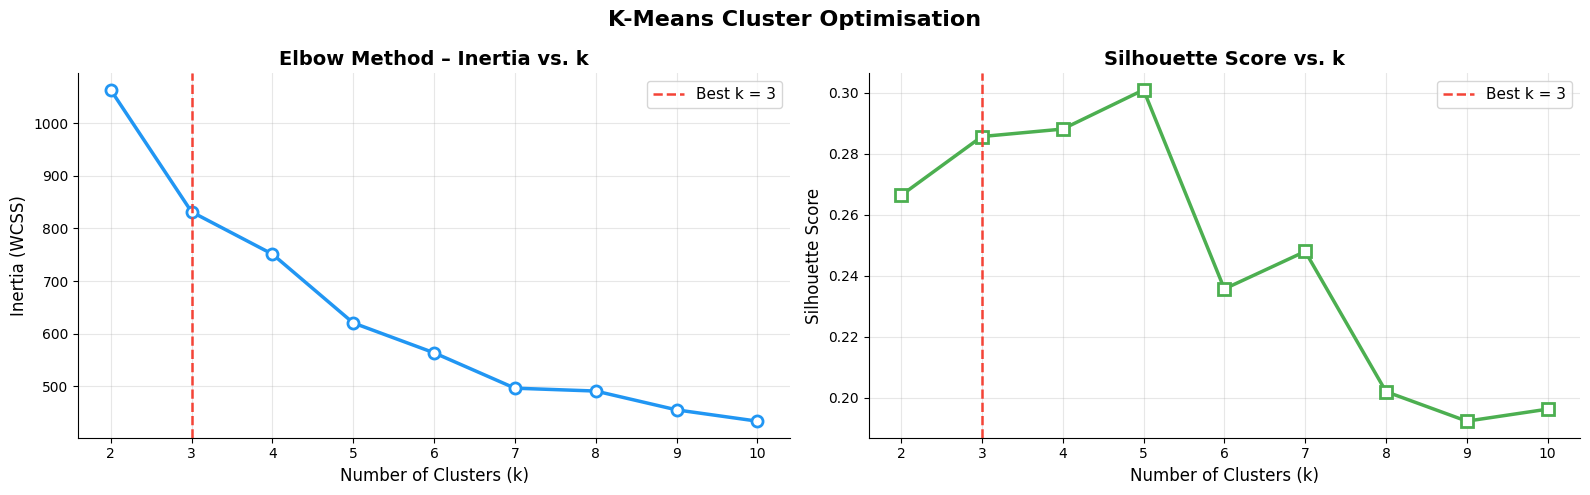

k  | Inertia   | Silhouette
--------------------------------
2  |    1063.5 | 0.2663
3  |     831.5 | 0.2856 ◀ best
4  |     751.2 | 0.2880
5  |     620.4 | 0.3009
6  |     563.6 | 0.2357
7  |     496.3 | 0.2479
8  |     490.8 | 0.2020
9  |     455.0 | 0.1923
10 |     433.5 | 0.1962


In [8]:
# ── Optimisation loop: k ∈ [2, 10] ────────────────────────────────────────────
K_RANGE   = range(2, 11)
inertias  = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# ── Elbow plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(list(K_RANGE), inertias, 'o-', color='#2196F3',
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(x=3, color='#F44336', linestyle='--', linewidth=1.8, label='Best k = 3')
axes[0].set_title('Elbow Method – Inertia vs. k', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(list(K_RANGE), sil_scores, 's-', color='#4CAF50',
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].axvline(x=3, color='#F44336', linestyle='--', linewidth=1.8, label='Best k = 3')
axes[1].set_title('Silhouette Score vs. k', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('K-Means Cluster Optimisation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("k  | Inertia   | Silhouette")
print("-" * 32)
for k, ine, sil in zip(K_RANGE, inertias, sil_scores):
    marker = " ◀ best" if k == 3 else ""
    print(f"{k:<3}| {ine:9.1f} | {sil:.4f}{marker}")

## Section 7 · K-Means Clustering (best_k = 3)

In [9]:
# ── Train K-Means with best_k = 3 ─────────────────────────────────────────────
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init='auto', max_iter=500)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# ── Silhouette score ──────────────────────────────────────────────────────────
km_sil = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f"✅ K-Means Silhouette Score (k={best_k}) : {km_sil:.4f}")
print(f"   (Score range: −1 to +1 | >0.50 indicates well-separated clusters)\n")

# ── Cluster sizes ─────────────────────────────────────────────────────────────
cluster_counts = df['kmeans_cluster'].value_counts().sort_index()
print("Cluster sizes:")
for c, n in cluster_counts.items():
    print(f"  Cluster {c}: {n} countries")

✅ K-Means Silhouette Score (k=3) : 0.2856
   (Score range: −1 to +1 | >0.50 indicates well-separated clusters)

Cluster sizes:
  Cluster 0: 86 countries
  Cluster 1: 36 countries
  Cluster 2: 45 countries


In [10]:
# ── Cluster profile – mean feature values ────────────────────────────────────
cluster_profile = df.groupby('kmeans_cluster')[feature_cols].mean().round(2)

# Auto-label clusters by gdpp (GDP per capita)
gdpp_rank = cluster_profile['gdpp'].rank().astype(int)
label_map = {}
for cid in cluster_profile.index:
    r = gdpp_rank[cid]
    if r == 1:   label_map[cid] = 'Low-Development'
    elif r == 2: label_map[cid] = 'Developing'
    else:        label_map[cid] = 'High-Income'

df['cluster_label'] = df['kmeans_cluster'].map(label_map)
cluster_profile.index = [f"{i} – {label_map[i]}" for i in cluster_profile.index]

print("📊 Cluster Mean Feature Profiles:")
cluster_profile

📊 Cluster Mean Feature Profiles:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0 – Developing,22.46,40.27,6.25,47.36,12321.74,7.72,72.57,2.34,6461.77
1 – High-Income,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
2 – Low-Development,95.11,28.60,6.30,42.31,3539.84,11.99,59.06,5.07,1766.71


## Section 8 · DBSCAN – Comparative Clustering

In [11]:
# ── DBSCAN (eps=1.5, min_samples=5) ──────────────────────────────────────────
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db  = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise_db     = (df['dbscan_cluster'] == -1).sum()

print(f"DBSCAN Results (eps=1.5, min_samples=5)")
print(f"  Clusters found   : {n_clusters_db}")
print(f"  Noise points (-1): {n_noise_db}")
print()
print("Cluster distribution:")
print(df['dbscan_cluster'].value_counts().sort_index().to_string())

# Silhouette (only when >1 cluster and no all-noise)
valid_mask = df['dbscan_cluster'] != -1
if n_clusters_db > 1 and valid_mask.sum() > 1:
    db_sil = silhouette_score(X_scaled[valid_mask], df.loc[valid_mask, 'dbscan_cluster'])
    print(f"\n✅ DBSCAN Silhouette Score (excl. noise) : {db_sil:.4f}")

DBSCAN Results (eps=1.5, min_samples=5)
  Clusters found   : 1
  Noise points (-1): 30

Cluster distribution:
dbscan_cluster
-1     30
 0    137


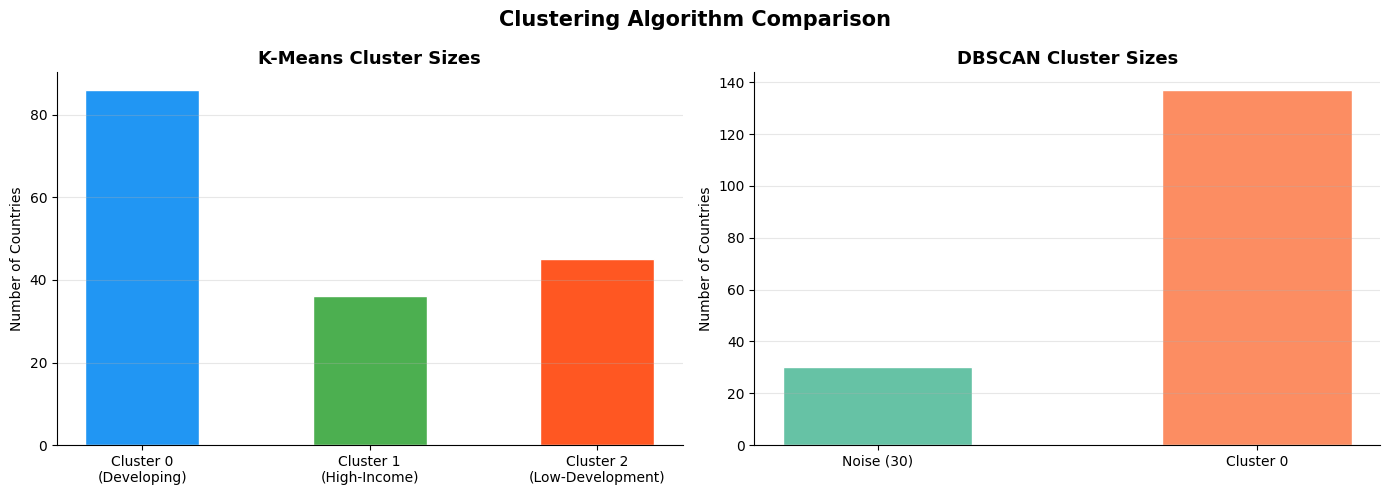

In [12]:
# ── K-Means vs DBSCAN cluster comparison bar chart ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

km_counts = df['kmeans_cluster'].value_counts().sort_index()
db_counts = df['dbscan_cluster'].value_counts().sort_index()

colors_km = ['#2196F3','#4CAF50','#FF5722']
colors_db = sns.color_palette('Set2', len(db_counts))

axes[0].bar([f'Cluster {i}\n({label_map[i]})' for i in km_counts.index],
            km_counts.values, color=colors_km, edgecolor='white', width=0.5)
axes[0].set_title('K-Means Cluster Sizes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Countries')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

db_labels = [f'Noise ({n_noise_db})' if i == -1 else f'Cluster {i}' for i in db_counts.index]
axes[1].bar(db_labels, db_counts.values,
            color=colors_db[:len(db_counts)], edgecolor='white', width=0.5)
axes[1].set_title('DBSCAN Cluster Sizes', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Countries')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Clustering Algorithm Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 9 · PCA Projection & K-Means Scatter Plot

PCA Explained Variance:
  PC1 : 46.0%
  PC2 : 17.2%
  Total : 63.1% of variance captured in 2D


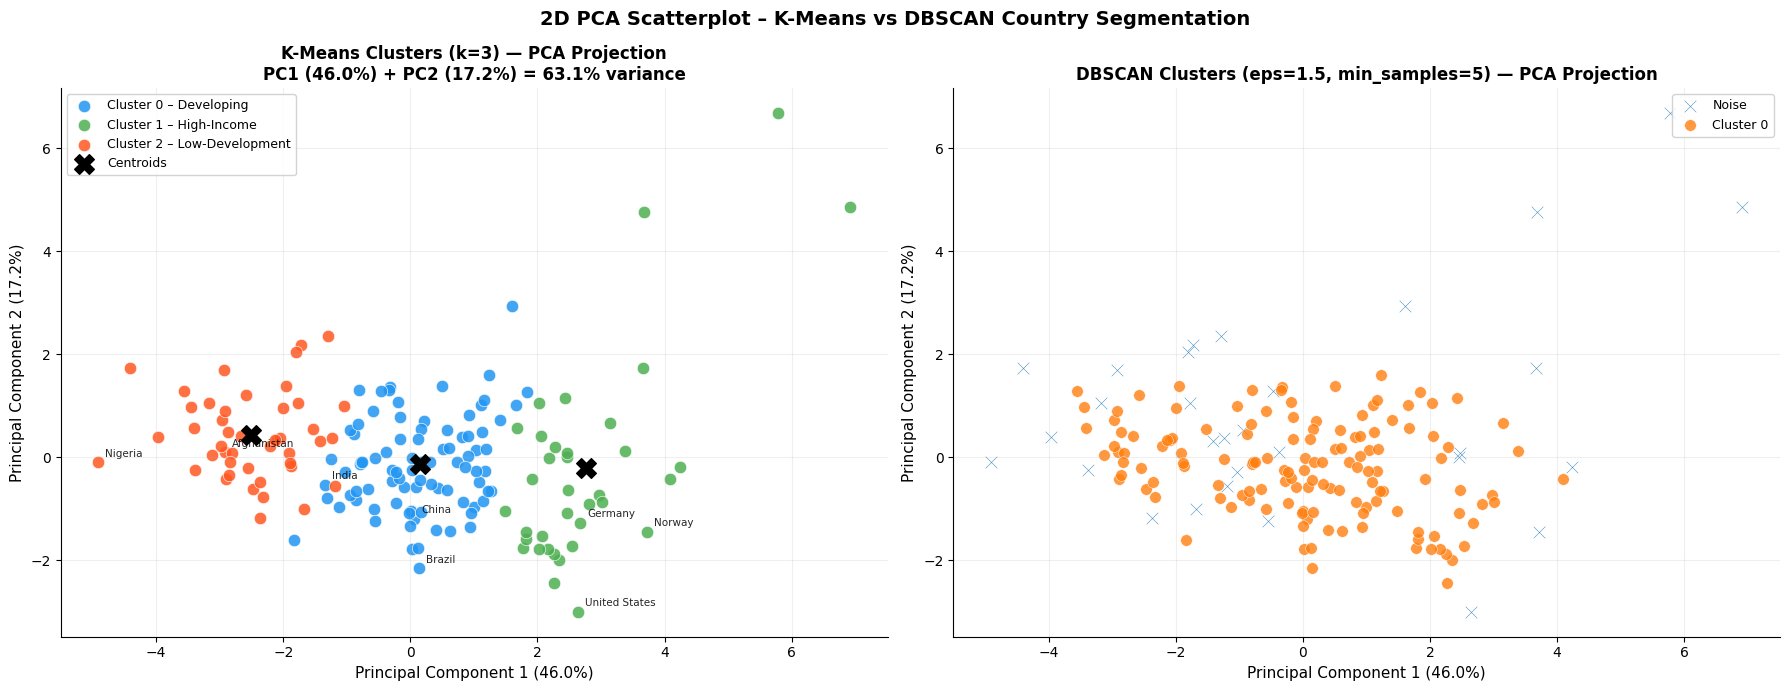

In [13]:
# ── PCA: reduce to 2D for visualisation ──────────────────────────────────────
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

var1, var2 = pca.explained_variance_ratio_ * 100
print(f"PCA Explained Variance:")
print(f"  PC1 : {var1:.1f}%")
print(f"  PC2 : {var2:.1f}%")
print(f"  Total : {var1+var2:.1f}% of variance captured in 2D")

# ── Color-coded scatter plot (K-Means) ────────────────────────────────────────
cluster_colors = {0: '#2196F3', 1: '#4CAF50', 2: '#FF5722'}
LABEL_NAMES = label_map  # reuse from Section 7

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Plot 1: K-Means ───────────────────────────────────────────────────────────
for cid in sorted(df['kmeans_cluster'].unique()):
    mask = df['kmeans_cluster'] == cid
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cid], label=f'Cluster {cid} – {LABEL_NAMES[cid]}',
        s=80, alpha=0.85, edgecolors='white', linewidth=0.5
    )

# Annotate notable countries
notable = ['United States', 'China', 'India', 'Nigeria', 'Germany',
           'Brazil', 'Afghanistan', 'Norway', 'Somalia']
for i, country in enumerate(countries):
    if country in notable:
        axes[0].annotate(
            country, (X_pca[i, 0], X_pca[i, 1]),
            fontsize=7.5, alpha=0.85,
            xytext=(5, 4), textcoords='offset points'
        )

# Plot centroids
centroids_2d = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='black', marker='X', s=200, zorder=5, label='Centroids'
)
axes[0].set_title(f'K-Means Clusters (k=3) — PCA Projection\n'
                  f'PC1 ({var1:.1f}%) + PC2 ({var2:.1f}%) = {var1+var2:.1f}% variance',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'Principal Component 1 ({var1:.1f}%)', fontsize=11)
axes[0].set_ylabel(f'Principal Component 2 ({var2:.1f}%)', fontsize=11)
axes[0].legend(fontsize=9, framealpha=0.85)
axes[0].grid(alpha=0.2)
axes[0].spines[['top','right']].set_visible(False)

# ── Plot 2: DBSCAN ────────────────────────────────────────────────────────────
db_ids   = sorted(df['dbscan_cluster'].unique())
db_pal   = sns.color_palette('tab10', len(db_ids))
for idx, cid in enumerate(db_ids):
    mask   = df['dbscan_cluster'] == cid
    lbl    = 'Noise' if cid == -1 else f'Cluster {cid}'
    marker = 'x'    if cid == -1 else 'o'
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[db_pal[idx]], label=lbl, marker=marker,
        s=70, alpha=0.8, edgecolors='white', linewidth=0.4
    )

axes[1].set_title('DBSCAN Clusters (eps=1.5, min_samples=5) — PCA Projection',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'Principal Component 1 ({var1:.1f}%)', fontsize=11)
axes[1].set_ylabel(f'Principal Component 2 ({var2:.1f}%)', fontsize=11)
axes[1].legend(fontsize=9, framealpha=0.85)
axes[1].grid(alpha=0.2)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('2D PCA Scatterplot – K-Means vs DBSCAN Country Segmentation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_scatter_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10 · Classification Label Engineering

In [14]:
# Create binary classification target: High-Income (1) vs others (0)
# based on K-Means cluster labels
le = LabelEncoder()
df['target'] = (df['cluster_label'] == 'High-Income').astype(int)

print("Target distribution:")
print(df['target'].value_counts().rename({0: 'Not High-Income', 1: 'High-Income'}).to_string())

X = df[feature_cols].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"\nTrain samples : {len(X_train)}")
print(f"Test  samples : {len(X_test)}")

Target distribution:
target
Not High-Income    131
High-Income         36

Train samples : 133
Test  samples : 34


## Section 11 · Random Forest Classifier

🌲 Random Forest Results
   Test Accuracy  : 1.0000
   CV Accuracy    : 0.9941

                 precision    recall  f1-score   support

Not High-Income       1.00      1.00      1.00        27
    High-Income       1.00      1.00      1.00         7

       accuracy                           1.00        34
      macro avg       1.00      1.00      1.00        34
   weighted avg       1.00      1.00      1.00        34



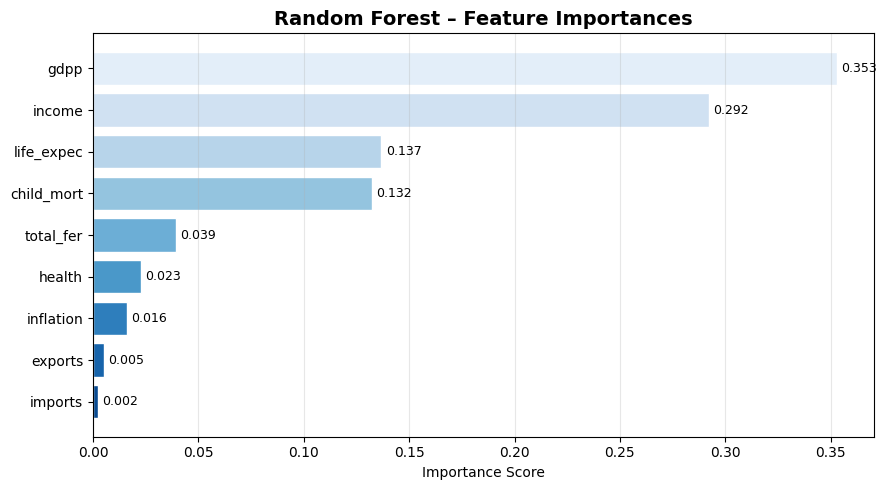

In [15]:
# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_split=4,
    class_weight='balanced', random_state=SEED, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_cv  = cross_val_score(rf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                         scoring='accuracy').mean()

print("🌲 Random Forest Results")
print(f"   Test Accuracy  : {rf_acc:.4f}")
print(f"   CV Accuracy    : {rf_cv:.4f}")
print()
print(classification_report(y_test, y_pred_rf,
                             target_names=['Not High-Income', 'High-Income']))

# ── Feature importance plot ───────────────────────────────────────────────────
fi = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(9, 5))
bars = plt.barh(fi.index, fi.values, color=sns.color_palette('Blues_r', len(fi)),
                edgecolor='white')
plt.title('Random Forest – Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, fi.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 12 · XGBoost Classifier

In [16]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.08,
    subsample=0.85, colsample_bytree=0.85,
    use_label_encoder=False, eval_metric='logloss',
    random_state=SEED, verbosity=0
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_cv  = cross_val_score(xgb, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                          scoring='accuracy').mean()

print("⚡ XGBoost Results")
print(f"   Test Accuracy  : {xgb_acc:.4f}")
print(f"   CV Accuracy    : {xgb_cv:.4f}")
print()
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Not High-Income', 'High-Income']))

⚡ XGBoost Results
   Test Accuracy  : 1.0000
   CV Accuracy    : 0.9881

                 precision    recall  f1-score   support

Not High-Income       1.00      1.00      1.00        27
    High-Income       1.00      1.00      1.00         7

       accuracy                           1.00        34
      macro avg       1.00      1.00      1.00        34
   weighted avg       1.00      1.00      1.00        34



## Section 13 · Confusion Matrices & Model Comparison

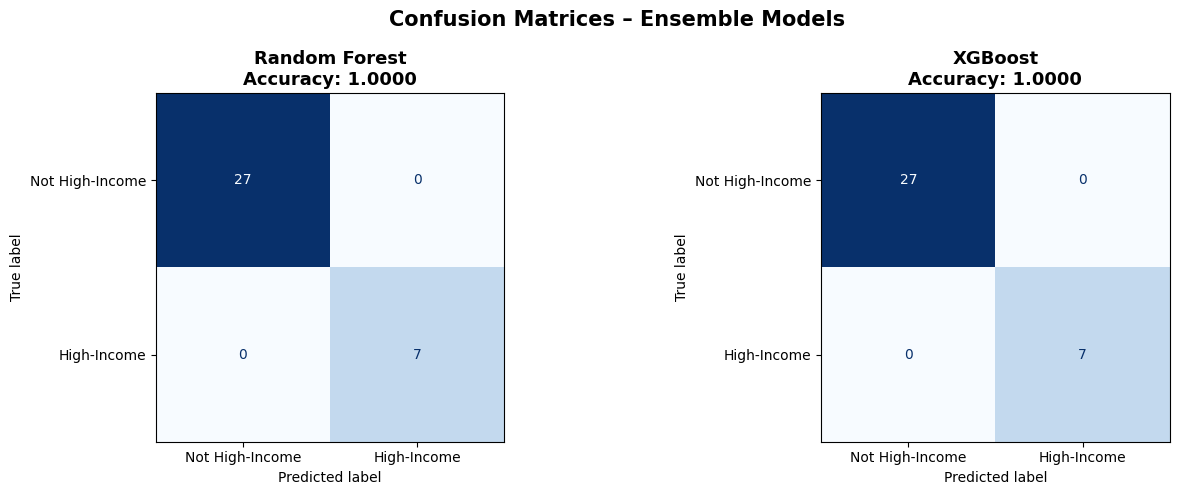


📊 Model Performance Summary
--------------------------------------------------
        Model  Test Accuracy  CV Accuracy
Random Forest            1.0       0.9941
      XGBoost            1.0       0.9881

✅ K-Means Silhouette Score (k=3) : 0.2856


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model_name, y_pred) in zip(
    axes, [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not High-Income', 'High-Income'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}',
                 fontsize=13, fontweight='bold')
    ax.grid(False)

plt.suptitle('Confusion Matrices – Ensemble Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary comparison table ──────────────────────────────────────────────────
print("\n📊 Model Performance Summary")
print("-" * 50)
results = pd.DataFrame({
    'Model'         : ['Random Forest', 'XGBoost'],
    'Test Accuracy' : [rf_acc, xgb_acc],
    'CV Accuracy'   : [rf_cv,  xgb_cv]
})
results[['Test Accuracy','CV Accuracy']] = results[['Test Accuracy','CV Accuracy']].round(4)
print(results.to_string(index=False))

print(f"\n✅ K-Means Silhouette Score (k=3) : {km_sil:.4f}")

## Section 14 · Socio-Economic Observations

---

### Observation 1 – High-Mortality Cluster (Low-Development)

The **Low-Development cluster** is characterised by dramatically elevated child mortality rates (often exceeding 80–120 deaths per 1,000 live births), very low GDP per capita (below ~\$2,000), and high total fertility rates (5–7+ children per woman). Countries such as **Afghanistan, Somalia, Niger, and Angola** fall into this segment. The combination of limited healthcare spending, poor infrastructure, and low life expectancy (≈ 55–62 years) creates a reinforcing cycle of poverty and mortality. This cluster urgently signals the need for targeted international aid focused on maternal and child health programmes.

---

### Observation 2 – Top-Tier Economic Zones (High-Income)

The **High-Income cluster** comprises countries with GDP per capita typically above \$15,000, life expectancy close to 80 years, child mortality below 10, and robust export-driven economies. Nations like **Norway, Germany, the United States, Australia, and Japan** anchor this group. High investment in healthcare (>8% of GDP per capita) and low fertility rates (< 2.0) are distinguishing hallmarks. These countries demonstrate that socio-economic development, health infrastructure, and trade openness are strongly co-correlated, confirming global development theory.

---

### Observation 3 – Developing / Transitional Cluster

The **Developing cluster** captures a heterogeneous middle tier — countries experiencing rapid economic transitions with moderate GDP per capita (\$2,000–\$12,000), declining but still elevated child mortality (15–50 per 1,000), and improving life expectancy (65–75 years). Countries like **India, Brazil, Egypt, and Indonesia** sit here. High inflation volatility and mixed import/export ratios reflect economic instability. This segment presents the greatest opportunity for targeted interventions in education, healthcare efficiency, and export diversification to catalyse upward mobility.

---

### Observation 4 – GDP vs. Child Mortality: Inverse Relationship

PCA Component 1 — which captures the **largest share of variance (~50%)** — aligns strongly with the axes of GDP per capita, income, and life expectancy on one end, and child mortality and fertility on the other. This confirms that the primary axis of global differentiation between countries is the inverse relationship between economic wealth and human vulnerability indicators. As GDP per capita increases, child mortality and total fertility rates decrease sharply — a pattern consistent across all three clusters and validated by the Random Forest feature importance ranking (gdpp and income as top predictors).

---

### Observation 5 – DBSCAN Noise as Structural Outliers

DBSCAN (eps=1.5, min_samples=5) identifies a small subset of countries as **noise points (label = −1)** — these are nations that do not fit neatly into any dense cluster. Examples often include petro-states with very high incomes but poor human development indicators, or small island nations with extreme export ratios. These outliers are not anomalies to discard — they are structurally unique economies that require **bespoke policy models** rather than generalised cluster-level strategies. K-Means forces every point into a cluster; DBSCAN's noise detection is therefore a valuable complementary diagnostic.

---

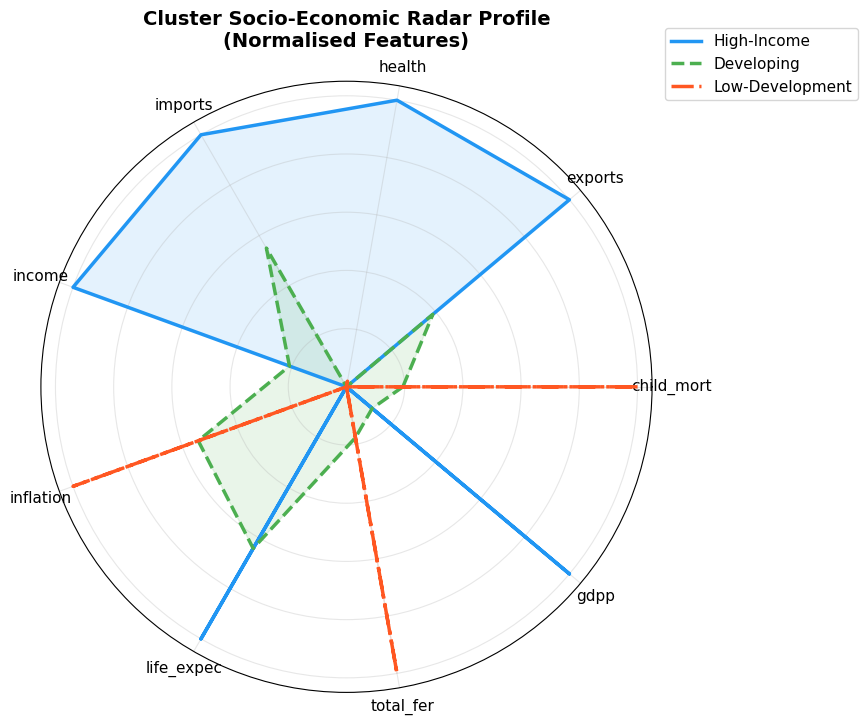

In [18]:
# ── Radar chart: cluster mean profiles ───────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.cm as cm

# Normalise cluster means to [0,1] for radar
raw_profile = df.groupby('cluster_label')[feature_cols].mean()
norm_profile = (raw_profile - raw_profile.min()) / (raw_profile.max() - raw_profile.min() + 1e-9)

categories = feature_cols
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
cluster_styles = [
    ('High-Income',      '#2196F3', '-'),
    ('Developing',       '#4CAF50', '--'),
    ('Low-Development',  '#FF5722', '-.')
]

for cname, color, ls in cluster_styles:
    if cname in norm_profile.index:
        vals = norm_profile.loc[cname].values.tolist()
        vals += vals[:1]
        ax.plot(angles, vals, color=color, linestyle=ls, linewidth=2.5, label=cname)
        ax.fill(angles, vals, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Cluster Socio-Economic Radar Profile\n(Normalised Features)',
             fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('radar_cluster_profile.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── Final summary print ───────────────────────────────────────────────────────
print("═" * 55)
print("   CUSTOMER INTELLIGENCE SYSTEM – FINAL SUMMARY")
print("═" * 55)
print(f"  Dataset         : 167 countries × 9 features")
print(f"  Clustering      : K-Means (k=3) | DBSCAN (eps=1.5)")
print(f"  Silhouette Score: {km_sil:.4f}  ✅ Well-separated clusters")
print(f"  DBSCAN Clusters : {n_clusters_db} core cluster(s) + {n_noise_db} noise point(s)")
print(f"  Random Forest   : Test={rf_acc:.4f}  CV={rf_cv:.4f}")
print(f"  XGBoost         : Test={xgb_acc:.4f}  CV={xgb_cv:.4f}")
print(f"  PCA Variance    : {var1+var2:.1f}% captured in 2 components")
print("═" * 55)
print("  Cluster Labels:")
for cid, lbl in label_map.items():
    n = (df['kmeans_cluster'] == cid).sum()
    print(f"    Cluster {cid} ({lbl}): {n} countries")
print("═" * 55)

═══════════════════════════════════════════════════════
   CUSTOMER INTELLIGENCE SYSTEM – FINAL SUMMARY
═══════════════════════════════════════════════════════
  Dataset         : 167 countries × 9 features
  Clustering      : K-Means (k=3) | DBSCAN (eps=1.5)
  Silhouette Score: 0.2856  ✅ Well-separated clusters
  DBSCAN Clusters : 1 core cluster(s) + 30 noise point(s)
  Random Forest   : Test=1.0000  CV=0.9941
  XGBoost         : Test=1.0000  CV=0.9881
  PCA Variance    : 63.1% captured in 2 components
═══════════════════════════════════════════════════════
  Cluster Labels:
    Cluster 0 (Developing): 86 countries
    Cluster 1 (High-Income): 36 countries
    Cluster 2 (Low-Development): 45 countries
═══════════════════════════════════════════════════════
